# Text classification :: Overview

## Task 

We want to build a Spam detector which, given examples of spam emails (e.g. flagged by users) and examples of regular (non-spam, also called "ham") emails, learns how to flag new unseen emails as spam or non-spam.

## Data

We will use the [SpamAssassin](https://spamassassin.apache.org/) public email corpus. This dataset contains ~6'000 labeled emails with a ~30% spam ratio. If you want to learn more about this dataset, check [this](https://spamassassin.apache.org/old/publiccorpus/). (*Note: Datasets of text are called corpora and samples are called documents.*) 

The dataset has been downloaded for you and is available in the *data* folder.

## Notebook overview

* Load the data
* Text preprocessing
* Data exploration
* Feature extraction
* Build a spam detector
* What did our model learn? Error analysis

# Text classification :: Spam detection


## Load the data

In [1]:
# Load libraries and helper functions
import tools

In [2]:
# Load the data
df = tools.load_data()

Data loaded.
Data size: (5832, 2)


Let's check the number of samples per class in the data.

Samples per class (%):
non-spam    70.3
spam        29.7
Name: proportion, dtype: float64




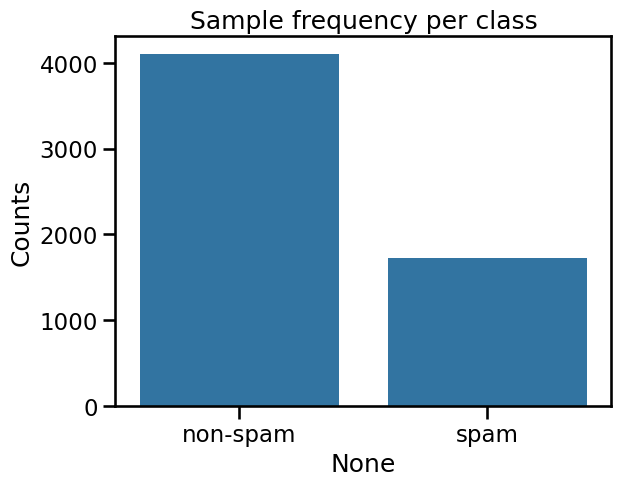

In [3]:
tools.plot_class_frequency(df)

Now, let's have a look at a few rows from the dataset.

***Note:*** The *label* is 0 for *non-spam* and 1 for *spam*.

In [4]:
# If you rerun this cell then you get a different set of samples displayed
df.sample(3)

,label,text
2013,0,"On Fri, 13 Sep 2002, Tony L. Svanstrom mused: > On Fri, 13 Sep 2002 the voices made carlo@alinoe.com write: > >> What do spammers do with email addresses in >> their database that are undeliverable for a >> few years? Do they still continue to spam >> them? > > Yes. So much so that I get thousands of bounces per day on this machine aimed at what are plainly message-ids... -- `Let's have a round of applause for those daring young men and their flying spellcheckers.' --- Meg Worley ------------------------------------------------------- This sf.net email is sponsored by:ThinkGeek Welcome to geek heaven. http://thinkgeek.com/sf _______________________________________________ Spamassassin-talk mailing list Spamassassin-talk@lists.sourceforge.net https://lists.sourceforge.net/lists/listinfo/spamassassin-talk"
5646,0,"On Sun, 11 Aug 2002, wintermute wrote: > Hmm... begs the question, why remove Handrick? andre seems to have a peculiar way of interacting with people on linux-kernel. martin otoh gets on fine with people, but doesnt /seem/ to have his head fully around the ide code yet¹. > If it ain't broke, don't fix it. however, how do you add features? eg tagged commands, udma100, 133, etc.. serial ATA, new chipsets. plus the IDE code might be fine, but lots of drives and chips have bugs, which need working around. all that said, Linus says he does his development on an IDE machine and hasnt had any problems. 1. judging from comments on l-k. regards, -- Paul Jakma paul@clubi.ie paul@jakma.org Key ID: 64A2FF6A warning: do not ever send email to spam@dishone.st Fortune: The surest way to remain a winner is to win once, and then not play any more. -- Irish Linux Users' Group: ilug@linux.ie http://www.linux.ie/mailman/listinfo/ilug for (un)subscription information. List maintainer: listmaster@linux.ie"
4900,0,"Ciaran Mac Lochlainn stated the following: > > SoloCDM wrote: > > > Liam Bedford stated the following: > > <edit> > > >> fdisk /mbr will restore a dos MBR.. it'll leave the partitions > >> alone. > > >> linux fdisk and deleting all partitions will actually leave LILO in > >> the MBR though. > > > While I am in Linux, the following message is the output when I > > execute fdisk /mbr, even though the drive is in read and write mode: > > > Unable to open /mbr > > > The mbr is on a separate drive -- not related to the Linux drive. > > fdisk /mbr is a DOS command - if you are in Linux you will be running > Linux fdisk, which doesn't have the /mbr option. The Linux equivalent > of ""fdisk /mbr"" is ""lilo -u /dev/hda"" (unless John Reilly was making > that up yesterday - I haven't tried it!) Thanks! In the past I tried ""lilo -u /dev/hda"" and it wouldn't work -- an original copy of the MBR must be in /boot directory for it to work. Which is exactly what I didn't have. The installation of Linux Mandrake didn't afford me that luxury. Also, I'm glad you cleared up the fdisk issue. I know better now -- previously I was under the impression that fdisk had a hidden switch. This is obviously not the case. -- Note: When you reply to this message, please include the mailing list and/or newsgroup address and my email address in To: ********************************************************************* Signed, SoloCDM -- Irish Linux Users' Group: ilug@linux.ie http://www.linux.ie/mailman/listinfo/ilug for (un)subscription information. List maintainer: listmaster@linux.ie"


## Text preprocessing

Good text preprocessing is an essential part of every NLP project!

Our goal here is to build a model that distinguishes non-spam from spam. The idea here is to "clean" and "standardize" raw text before feeding it to our machine learning model. We need to keep as many "informative" words as possible, while discarding the "uniformative" ones. Removing unnecessary content, i.e. the "noise", from our texts will help to improve the accuracy of our models.

<div class="alert alert-success">
<h3>Questions</h3>
    
Take a few minutes to look at the raw text.
    
__Q1.__ Which parts of the text do you think should be removed to make it readable?
    
__Q2.__ How could the parts that we have just removed for text cleaning still be useful for the distinction of spam and non-spam?
</div>

### Answers

__Q1.__ Here are some suggestions of what could be removed or changed in order to clean the text:

* 
* 
* 
* 
* ...

__Q2.__ Your ideas:




The *clean_corpus* function below will take care of the parts raised by Question 1.

For the ideas from Question 2 we will create new features and investigate their effects in the subsection **What about "spammish" signatures?**. 

In [5]:
df = tools.clean_corpus(df)

print("Data cleaned")

Data cleaned


Let's have a look at a few "cleaned" examples.

In [6]:
tools.show_clean_text(df)


Original document:

| Date: Wed, 31 Jul 2002 18:57:50 +0100 | From: Brian Foster <blf@utvinternet.ie> | | | Date: Wed,
31 Jul 2002 23:11:49 +0800 | | From: Fergal Daly <fergal@esatclear.ie> | | | | 7.3 seems to support
Chinese input out of the box, it's got | | miniChinput and some other stuff no documentation. [ ...
] | | Can anyone tell me what I should do? | | I've no idea, but a relevant/useful source of info
could | be the Â«linux-utf8Â» e-list: | | http://www.cl.cam.ac.uk/~mgk25/unicode.html |
http://mail.nl.linux.org/linux-utf8/ |[ ... ] | w.r.t. X11 applications [ one approach is to use ] |
what's called an XIM (X Input Method). [ ... ] sorry for replying to my own post! a google for "xim
linux" found a number of hits. try (I've haven't finished reading this myself, but it seems good):
http://www.suse.de/~mfabian/suse-cjk/ (CJK stands for Chinese Japanese Korean.) the above is
probably best read with a browser that groks UTF-8. cheers! -blf- -- Innovative, very experienced,
Un

## Data Exploration :: What makes spam distinct?

### Frequent words

Which words distinguish spam from non-spam? Can we  identify the words in a text that are the most informative about its topic?

Let's find the 10 most frequent words in spam and non-spam and compare them.

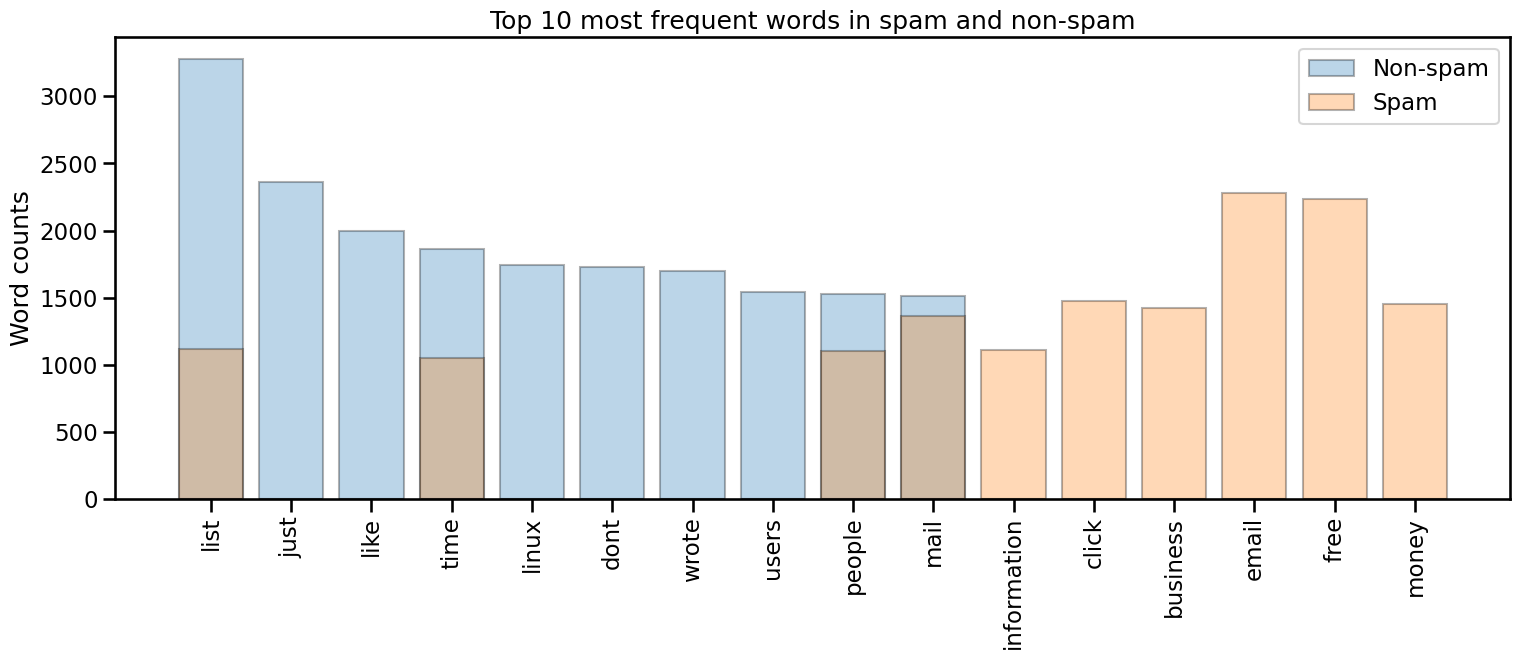

In [7]:
tools.plot_most_common_words(df=df, N=10)

<div class="alert alert-success">
<h3>Questions</h3>
    
__Q1.__ Which of the top 10 most frequent "spammish" words are unique to that class?

__Q2.__ Which of the top 10 most frequent "non-spammish" words are unique to that class?
     
__Q3.__ For the words that occur in both lists, which ones are likely still useful for distinguishing the classes?
    
__Q4.__ Which ones are likely not?
    
    
</div>

### Answers

__Q1.__ **Frequent "spammish" words**: 

* 
* 
* 


__Q2.__ **Frequent "non-spammish" words**:
* 
* 
* 


__Q3.__ **Occur in both top 10 but could be useful for distinctions**:
* 
* 
* 

__Q4.__ **Occur in both top 10 but are unlikely to be useful**:
* 
* 
* 

<div class="alert alert-success">
<h3>Task 1</h3>
    
Change `N=10` to `N=30` and compare the outcome.
</div>

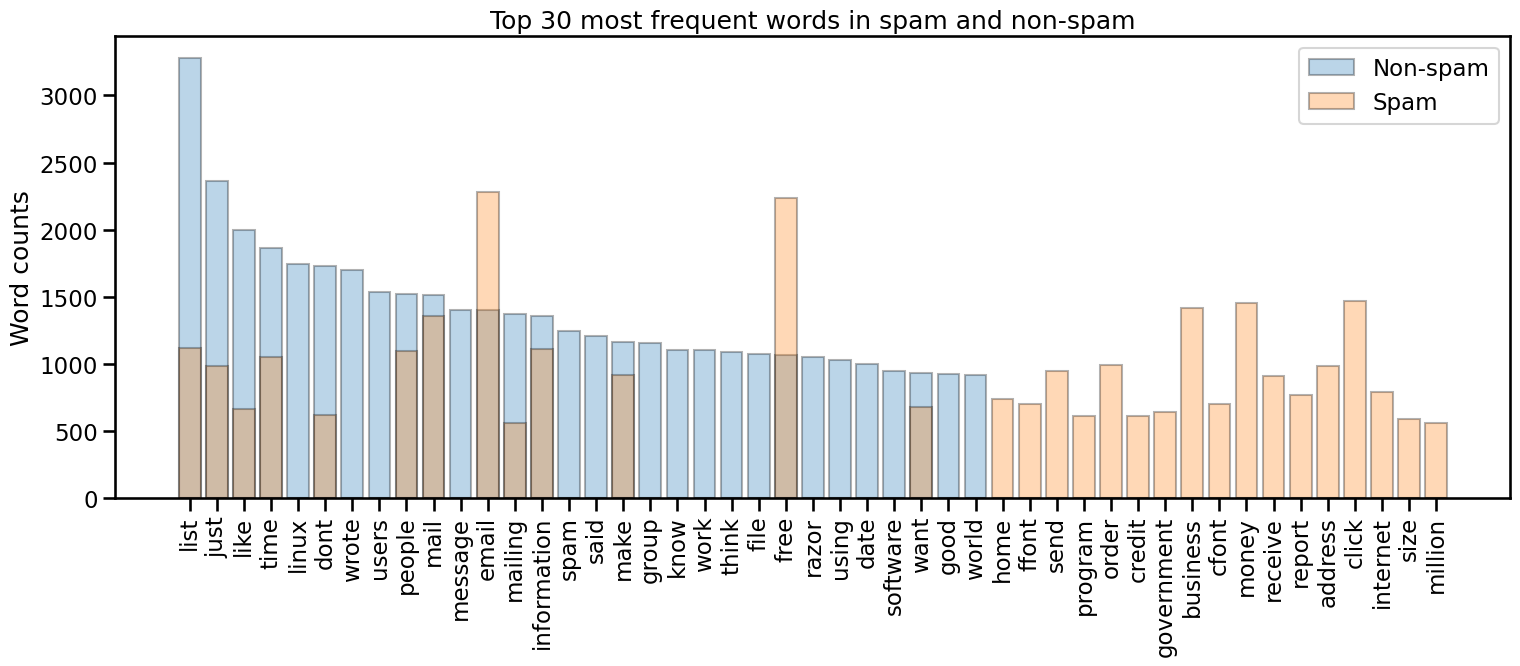

In [8]:
tools.plot_most_common_words(df=df, N=30)

### Observation

Add your obsevation here

### What about "spammish" signatures?

* Do spams contain more HTML tags? 
* Does non-spam contain more URLs and E-mail adresses? 
* Are spams mails longer than non-spam? 
* ...

Let's find out!

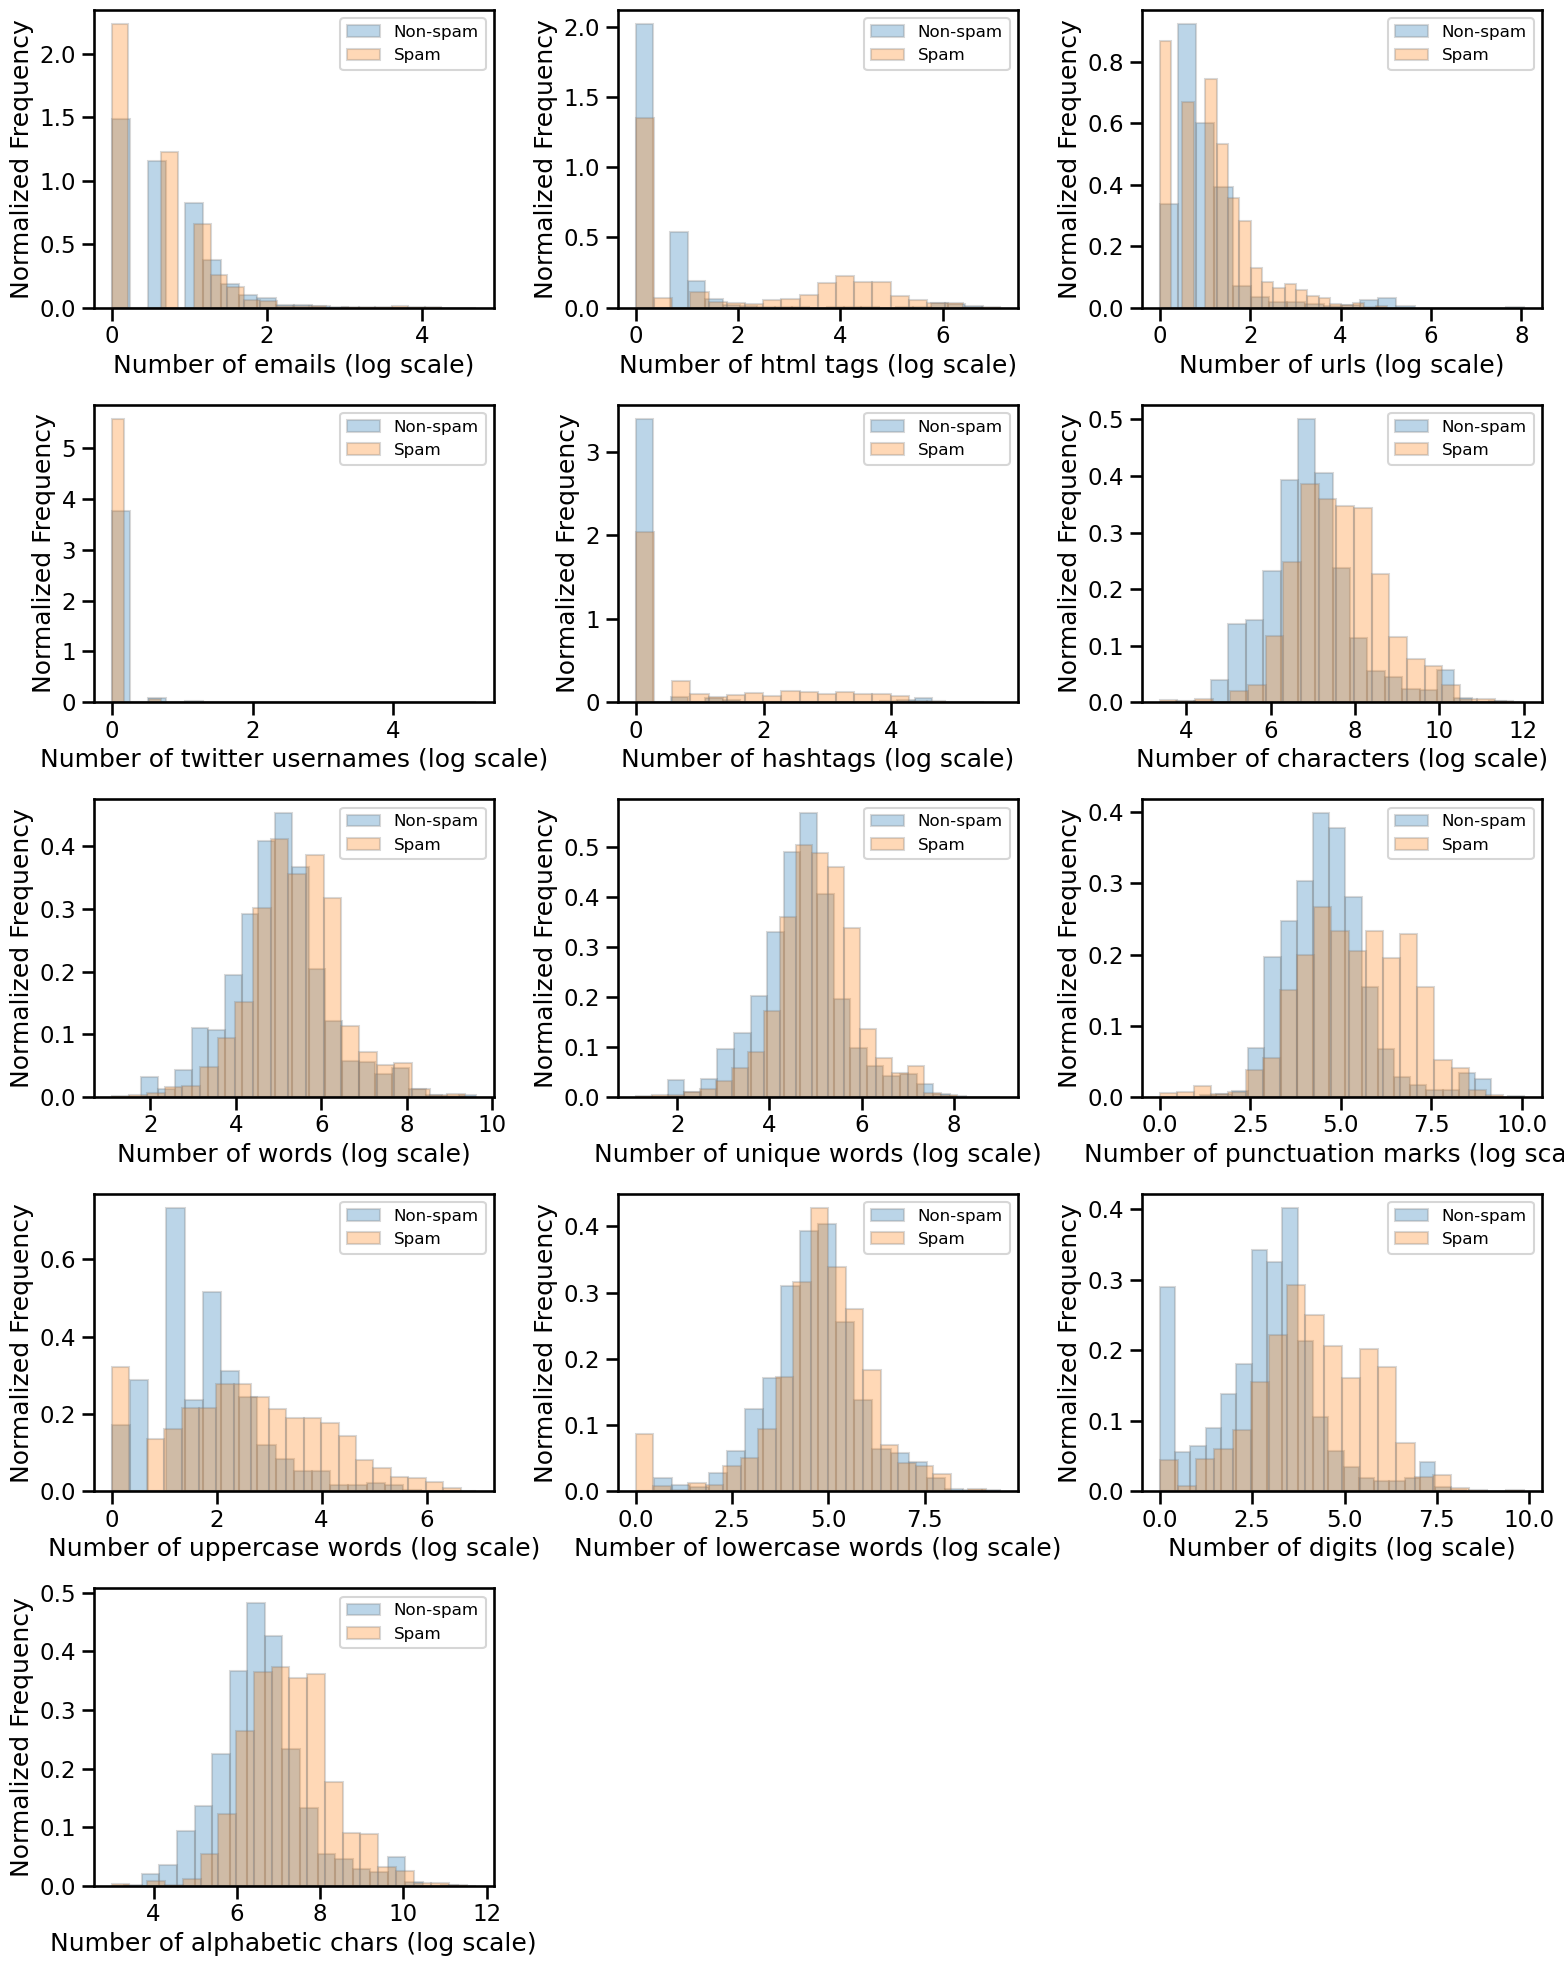

In [9]:
features = tools.get_features(df=df)

## Feature engineering :: Extracting features from text

Computers don't understand natural language. So, how do we represent text?

One of the simplest but effective and commonly used models to represent text for machine learning is the ***Bag of Words*** model ([online documentation](https://en.wikipedia.org/wiki/Bag-of-words_model)). When using this model, we discard most of the structure of the input text (word order, chapters, paragraphs, sentences and formating) and only count how often each word appears in each text. Discarding the structure and counting only word occurencies leads to the mental image of representing text as a "bag".  

**Example:** Let our toy corpus contain four documents.

$ corpus = ['I\;enjoy\;paragliding.',  $  
$\hspace{2cm}'I\;like\;NLP.',$  
$\hspace{2cm}'I\;like\;deep\;learning.',$  
$\hspace{2cm}'O\;Captain!\;my\;Captain!']$ 

In [10]:
tools.show_bag_of_words_vector()

,captain,deep,enjoy,i,learning,like,my,nlp,o,paragliding
Text,,,,,,,,,,
I enjoy paragliding.,0,0,1,1,0,0,0,0,0,1
I like NLP.,0,0,0,1,0,1,0,1,0,0
I like deep learning.,0,1,0,1,1,1,0,0,0,0
O Captain! my Captain!,2,0,0,0,0,0,1,0,1,0


Bag of Words has converted all documents into numeric vectors. Each column represents a word from the corpus and each row one of the four documents. The value in each cell represents the number of times that word appears in a specific document. For example, the fourth document has the word `captain` occuring twice and the words `my` and `O` occuring once.

## Build a spam detector

In the previous section, we saw how to perform text preprocessing and feature extraction from text. We are now ready to build our machine learning model for detecting spams. We will use a Logistic Regression classifier ([online documentation](https://en.wikipedia.org/wiki/Logistic_regression)).

First, we need to split the data into two sets: the `train` set and the `test` set. We will then use the train set to `fit` our model. The test set will be used to `evaluate` the performance of our model. 

### Spam classification

<Axes: title={'center': 'Confusion matrix'}, xlabel='Predicted label', ylabel='True label'>

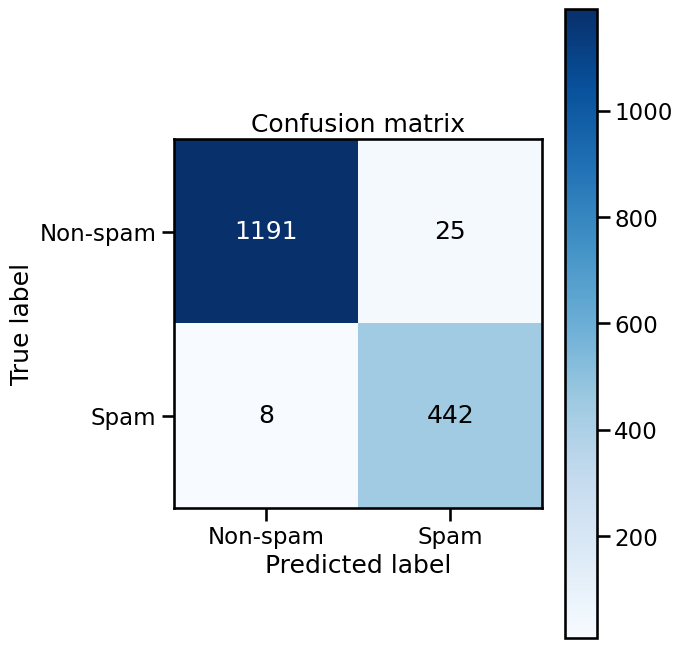

In [11]:
# Train/test splitting
df_train, df_test = tools.train_test_split_(df)

# Fit model on the train data
model = tools.fit_model(df_train)

# Print predictions on test set
tools.plot_confusion_matrix(df_test, model)

**Confusion matrices**  

Confusion matrices are a nice way of evaluating the performance of models for classification models. Rows correspond to the true classes and the columns to the predicted classes. Entries on the main diagonal of the confusion matrix correspond to correct predictions while the other cells tell us how many mistakes made our model ([online documentation]((https://en.wikipedia.org/wiki/Confusion_matrix))).

* The first row represents non-spam mails: 1'187 were correctly classified as 'non-spam', while 29 (~2,3%) were misclassified as 'spam'.
* The second row represents spam mails: 437 were correctly classified as 'spam', while 13 (~2,8%) were misclassified as 'non-spam'.

Our model did quite well!

### What did our model learn from the data?

Our logistic regression model has learned which words are the most indicative of non-spam and which words are the most indicative of spam. The positive coefficients on the right correspond to words that, according to the model, are indicative of spam. The negative coefficients on the left correspond to words that, according to the model, are indicative of non-spam.

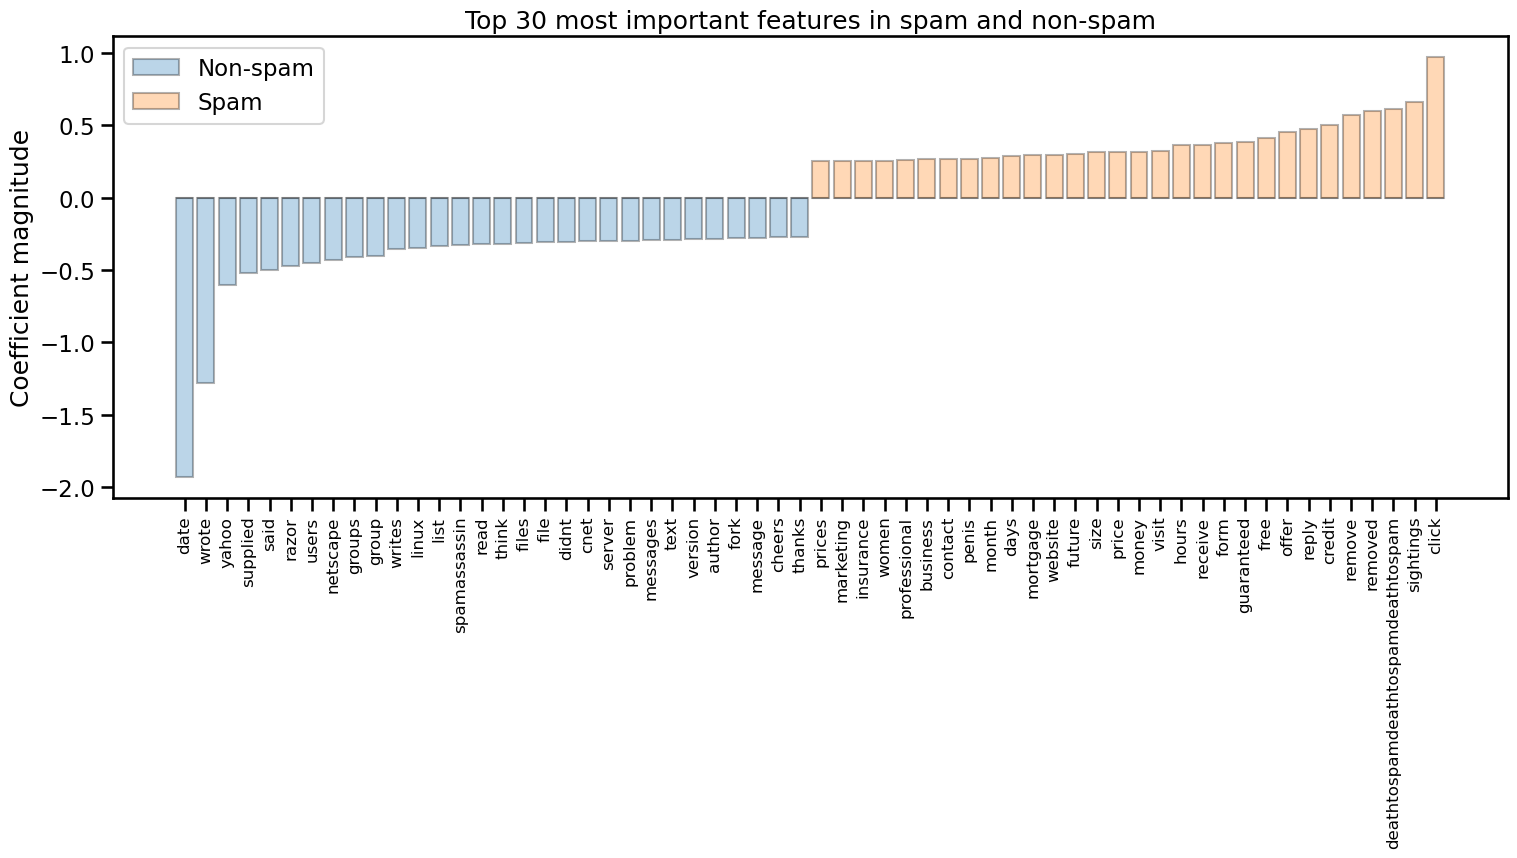

In [12]:
tools.visualize_coefficients(model, n_top_features=30)

<div class="alert alert-success">
<h3>Questions</h3>
    
__Q1.__ According to the model which words are strong indicators of non-spam, respectively spam? 
    
__Q2.__ Do they overlap with the results of our analysis?<br>
    
</div>

### Answers

__Q1.__ 


__Q2.__ 

### Error analysis :: Where does our model fail?

We will now analyze the misclassified mails in order to get some insights on where the model failed to make correct predictions. The *error_analysis* function below will show us the top features responsible for the model making a decision of prediction whether the mail is spam or non-spam.

Document index: 16 


Original Text
Dear Reader, How has Veuve Clicquot's sponsorship become so successful? Naomi Hancock,= =20 UK PR
Manager, tells us all about it in an exclusive interview. Also read= =20 about the launch of
SponsorRating, the first sponsorship rating agency,=20 our unsual transactions of the month, and a
"special X-treme" Sponsorship= =20 Alert. As this is the last issue for the summer, we wish you a
good August and=20 will be back in September. Your comments are always welcome, so please email us
at=20 news@sponsorclick.com. All our best, Rachael Mark Editor In this issue: 1. Sponsorship, How
and Why? Veuve Clicquot Speaks=20 2. Press Release: SponsorClick Launches the First Sponsorship
Ratin= g=20 Agency 3. Unusual Transactions of the Month 4. Sponsorship Alert Special X-treme 5.
Special Offers: Taylor Nelson Sofr=E8s, BVA, Sport+Markt,=20 Mediametrie, and more 6. More Matching
Opportunities With SponsorClick 7. How to Contact SponsorClick? =20 =20
---------------

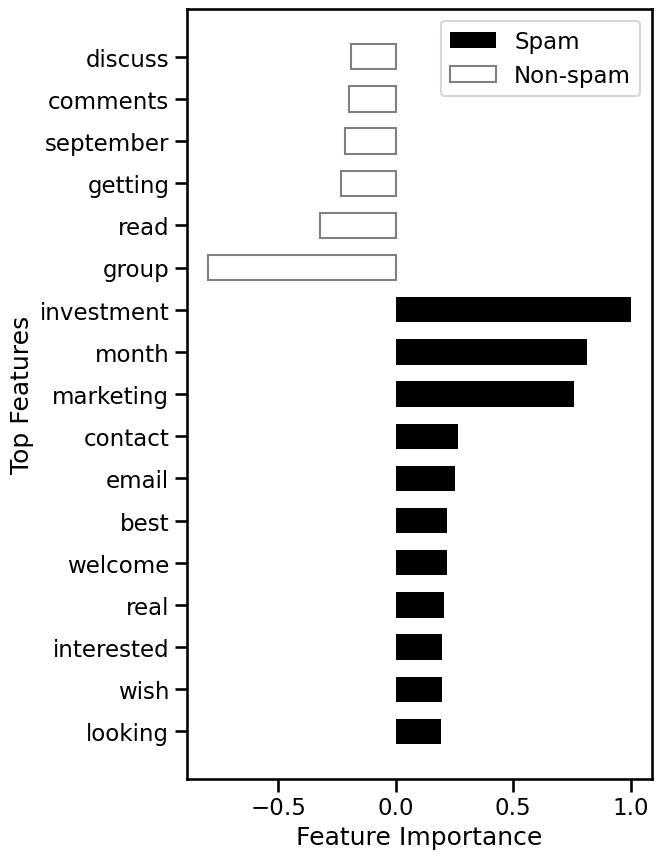

In [13]:
tools.error_analysis(df_test, model, doc_nbr=16)

<div class="alert alert-success">
<h3>Task 2</h3>
    
Let's change the `doc_nbr`.
</div>